# StreamLoop — Customer Churn Exploratory Data Analysis

StreamLoop's customer data is publicly modeled after the well-known **IBM Telco Customer Churn** dataset. This notebook follows a simple, step-by-step EDA workflow: import libraries → load data → analyze → prepare → visualize → build a baseline model.

**Target:** `Churn` (`Yes` / `No`) — did the customer leave. The remaining columns are customer *account*, *service*, and *billing* attributes.

## Step 1: Import the required libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

## Step 2: Load the dataset

We load StreamLoop's churn data **directly from the public URL** — no manual download needed.

- **Target:** `Churn` — `Yes` (left) / `No` (stayed).
- **Demographics:** `gender`, `SeniorCitizen`, `Partner`, `Dependents`.
- **Services:** `PhoneService`, `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`.
- **Account / billing:** `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`, `MonthlyCharges`, `TotalCharges`.

In [2]:
URL = (
    'https://raw.githubusercontent.com/IBM/'
    'telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv'
)
df = pd.read_csv(URL)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3: Data analysis

Get familiar with the shape, columns, data types, summary statistics and the target balance.

In [3]:
print('Shape:', df.shape)
df.info()

Shape: (7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   s

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
print('Duplicate rows:', df.duplicated().sum())
df['Churn'].value_counts()

Duplicate rows: 0


Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Step 4: Data preparation

- Drop the `customerID` identifier (not predictive).
- `TotalCharges` loads as text because a few brand-new customers have a blank value — coerce it to numeric and fill the resulting missing values.
- Encode the target `Churn` as `1` (Yes) / `0` (No).

In [6]:
# Drop the identifier column
df = df.drop(columns=['customerID'])

# TotalCharges has blank strings for brand-new customers -> coerce to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Missing values after coercion:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values after coercion:
TotalCharges    11
dtype: int64


In [7]:
# Fill the few missing TotalCharges with the median, then encode the target
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('Remaining missing values:', int(df.isnull().sum().sum()))
print('Churn rate: {:.1%}'.format(df['Churn'].mean()))

Remaining missing values: 0
Churn rate: 26.5%


## Step 5: Exploratory data analysis

Visualize the target and its relationship with the numeric and categorical attributes (univariate, bivariate and multivariate views).

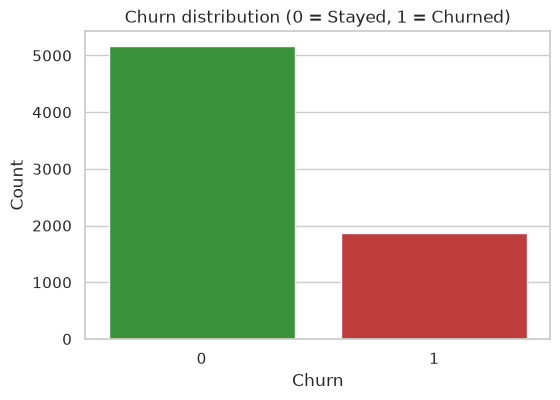

In [8]:
# Target distribution (univariate)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, hue='Churn', palette=['#2ca02c', '#d62728'], legend=False)
plt.title('Churn distribution (0 = Stayed, 1 = Churned)')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

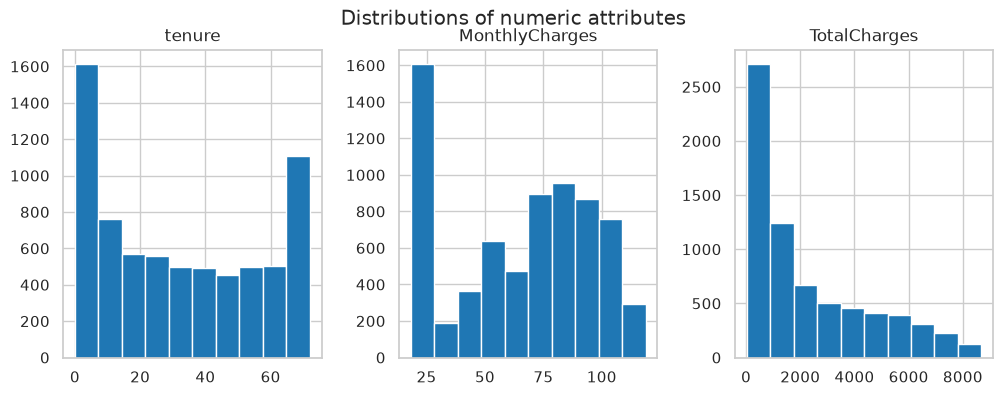

In [9]:
# Distributions of the numeric attributes (univariate)
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numeric_cols].hist(figsize=(12, 4), layout=(1, 3), color='#1f77b4', edgecolor='white')
plt.suptitle('Distributions of numeric attributes')
plt.show()

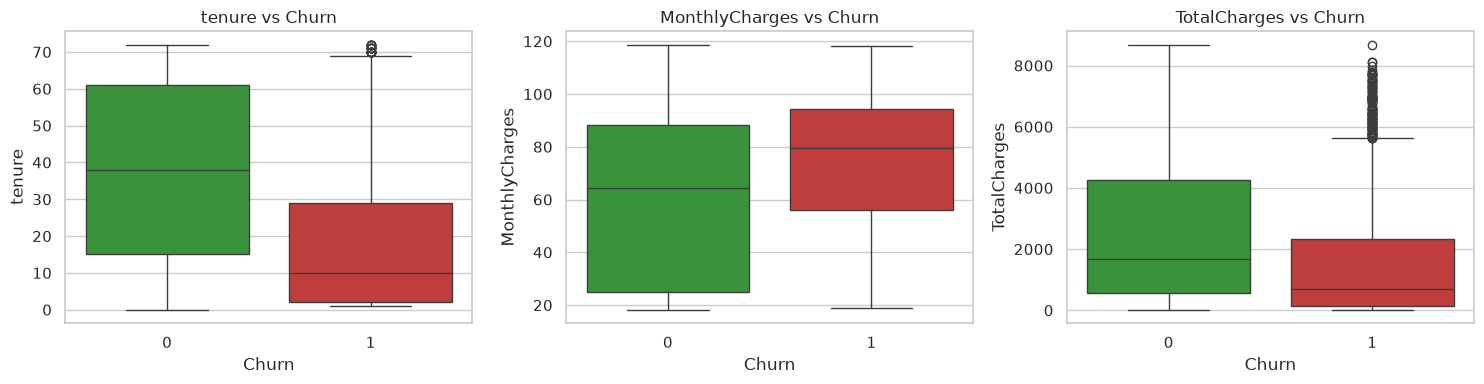

In [10]:
# Numeric attributes vs Churn (bivariate)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x='Churn', y=col, data=df, hue='Churn',
                palette=['#2ca02c', '#d62728'], legend=False, ax=ax)
    ax.set_title(f'{col} vs Churn')
plt.tight_layout()
plt.show()

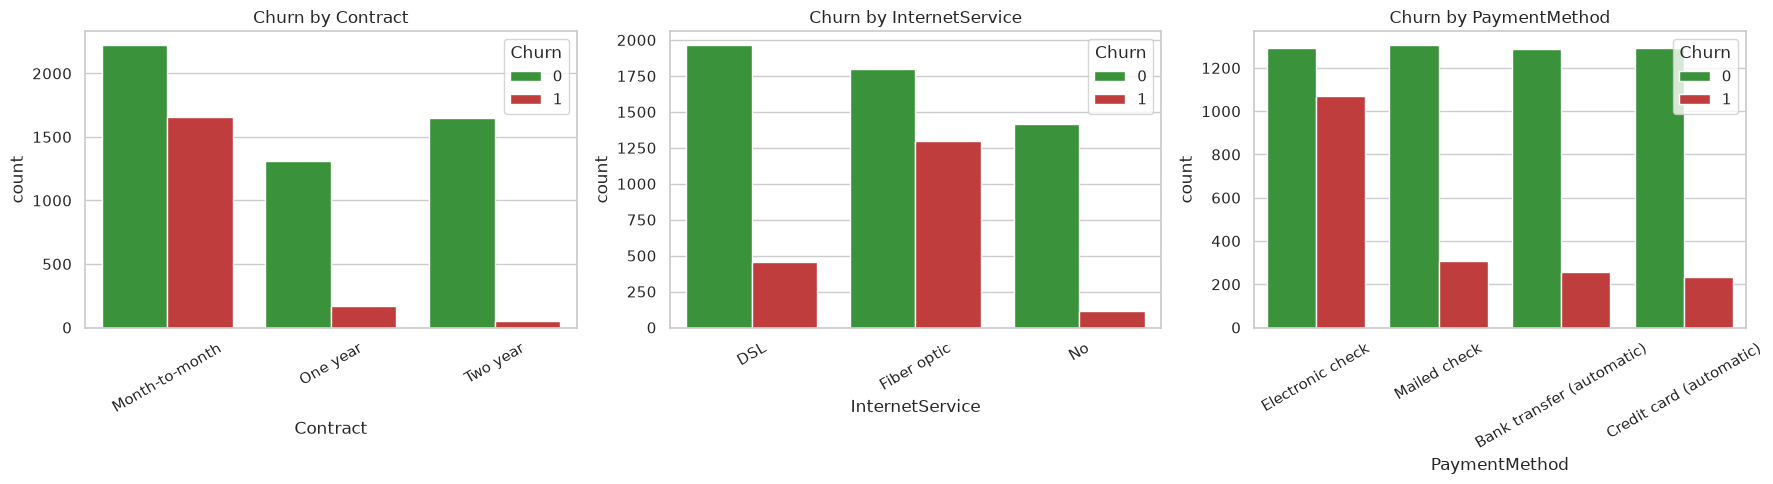

In [11]:
# Churn across key categorical attributes (bivariate)
cat_cols = ['Contract', 'InternetService', 'PaymentMethod']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, cat_cols):
    sns.countplot(x=col, hue='Churn', data=df, palette=['#2ca02c', '#d62728'], ax=ax)
    ax.set_title(f'Churn by {col}')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

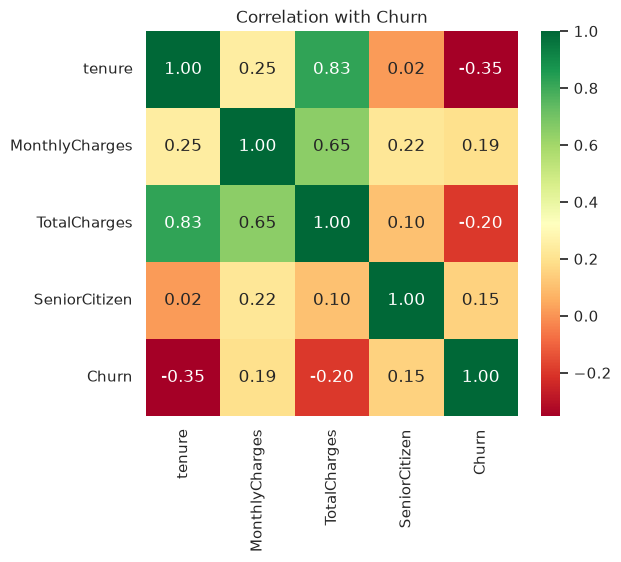

In [12]:
# Correlation of numeric attributes with Churn (multivariate)
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols + ['SeniorCitizen', 'Churn']].corr(),
            annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation with Churn')
plt.show()

## Step 6: Model building

One-hot encode the categorical attributes, split into train/test (stratified on the target), and standardize the features.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-hot encode the categorical columns
df_model = pd.get_dummies(df, drop_first=True)

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (4930, 30) | Test: (2113, 30)


## Step 7: Logistic Regression

Train a baseline classifier and evaluate it with a confusion matrix and accuracy.

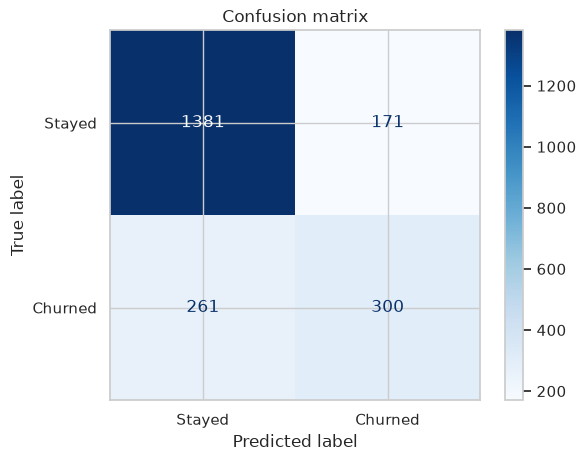

Accuracy: 79.56%


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred = logreg.predict(X_test_scaled)

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred), display_labels=['Stayed', 'Churned']
).plot(cmap='Blues')
plt.title('Confusion matrix')
plt.show()

print('Accuracy: {:.2%}'.format(accuracy_score(y_test, y_pred)))

## Step 8: Beyond accuracy — precision, recall & ROC-AUC

Accuracy is misleading on an imbalanced target (~26% churn). We add a classification report and ROC-AUC, and re-fit logistic regression with `class_weight='balanced'` so it catches more churners.

In [15]:
from sklearn.metrics import classification_report, roc_auc_score

# Balanced logistic regression to counter the class imbalance
logreg_bal = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg_bal.fit(X_train_scaled, y_train)
y_pred_bal = logreg_bal.predict(X_test_scaled)
y_proba_bal = logreg_bal.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_bal, target_names=['Stayed', 'Churned']))
print('ROC-AUC: {:.3f}'.format(roc_auc_score(y_test, y_proba_bal)))

              precision    recall  f1-score   support

      Stayed       0.92      0.73      0.81      1552
     Churned       0.52      0.81      0.64       561

    accuracy                           0.75      2113
   macro avg       0.72      0.77      0.72      2113
weighted avg       0.81      0.75      0.77      2113

ROC-AUC: 0.846


## Step 9: Compare models

Compare the baseline logistic regression with tree-based models on **ROC-AUC** — a threshold-independent metric well suited to imbalanced data.

In [16]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced', random_state=0
    ),
    'Gradient Boosting': GradientBoostingClassifier(random_state=0),
}

results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, model.predict(X_test_scaled)),
        'roc_auc': roc_auc_score(y_test, proba),
    })

pd.DataFrame(results).sort_values('roc_auc', ascending=False).reset_index(drop=True)

,model,accuracy,roc_auc
0,Gradient Boosting,0.799811,0.846070
1,Logistic Regression,0.752958,0.845636
2,Random Forest,0.768102,0.829537


## Step 10: What drives churn? (feature importance)

Rank the features by their influence on churn using the Random Forest's impurity-based importances.

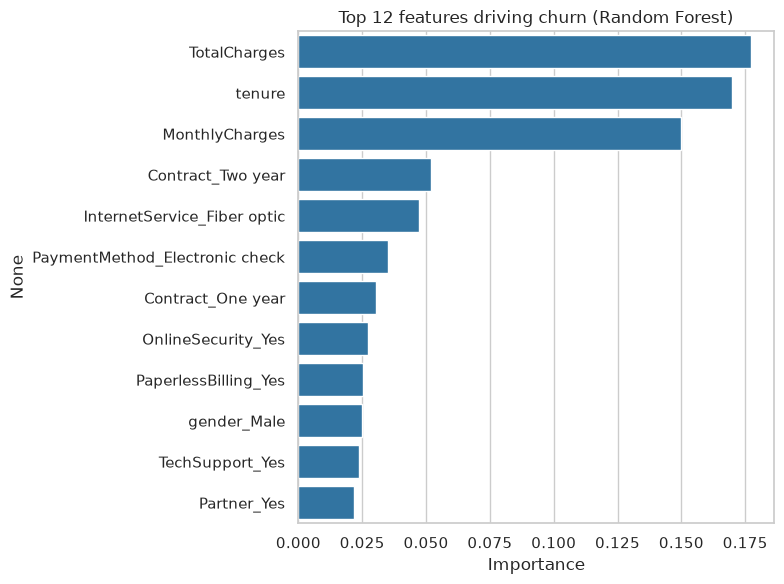

TotalCharges                      0.177398
tenure                            0.169693
MonthlyCharges                    0.149957
Contract_Two year                 0.052058
InternetService_Fiber optic       0.047116
PaymentMethod_Electronic check    0.035093
Contract_One year                 0.030311
OnlineSecurity_Yes                0.027209
PaperlessBilling_Yes              0.025124
gender_Male                       0.024995
TechSupport_Yes                   0.023613
Partner_Yes                       0.021800
dtype: float64

In [17]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=0)
rf.fit(X_train_scaled, y_train)

importances = (
    pd.Series(rf.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(12)
)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color='#1f77b4')
plt.title('Top 12 features driving churn (Random Forest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

importances

## Conclusion

- The dataset is **imbalanced** — only ~26.5% of customers churn — so **accuracy alone is misleading**; we also track precision/recall and ROC-AUC.
- **Baseline logistic regression** reaches ~79.6% accuracy but misses many churners. Adding `class_weight='balanced'` lifts **churn recall to 0.81** (ROC-AUC 0.846) — far more useful for retention, since catching at-risk customers matters more than raw accuracy.
- **Model comparison (ROC-AUC):** Gradient Boosting ≈ 0.846 (acc 0.80) ≈ balanced Logistic Regression 0.846 > Random Forest 0.83. Gradient Boosting is the strongest baseline.
- **Top churn drivers (Random Forest importance):** `TotalCharges`, `tenure`, `MonthlyCharges`, then **two-year contract** (protective), **fiber-optic internet**, and **electronic-check** payment.
- **So what for StreamLoop:** prioritize retention offers for **low-tenure, month-to-month, high-monthly-charge** customers on fiber/electronic-check; longer contracts are the strongest churn reducer.